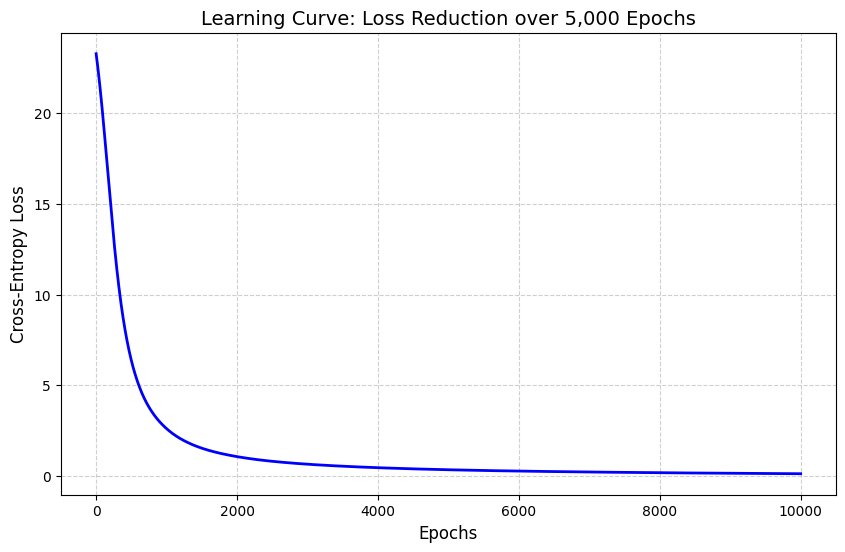

In [1]:
from matplotlib import pyplot as plt
import numpy as np

X_train_final = np.load('data/X_train_final.npz')['data']
y_train = np.load('data/y_train.npz')['data']
X_test_final = np.load('data/X_test_final.npz')['data']
y_test = np.load('data/y_test.npz')['data']

mean = X_train_final.mean(axis=0)
std = X_train_final.std(axis=0)

X_train = (X_train_final - mean) / std
X_test = (X_test_final - mean) / std


def one_hot(y, num_classes):
    out = np.zeros((len(y), num_classes))
    for i in range(len(y)):
        out[i, int(y[i])] = 1
    return out


def softmax(logits):
    exps = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)


def gradient_step(X, y_onehot, probs, W, b, lr):
    error = probs - y_onehot
    num_samples = X.shape[0]

    dW = (1 / num_samples) * (X.T @ error)
    db = (1 / num_samples) * np.sum(error, axis=0)

    W -= lr * dW
    b -= lr * db

    return W, b

def cross_entropy_loss(y_onehot, probs):
    eps = 1e-12
    probs = np.clip(probs, eps, 1.0)
    return -np.mean(np.sum(y_onehot * np.log(probs), axis=1))

if __name__ == '__main__':
    y_train_oh = one_hot(y_train, 28)
    y_test_oh = one_hot(y_test, 28)

    n_features = X_train.shape[1]

    W = np.random.randn(n_features, 28)
    b = np.random.randn(28)

    lr = 0.1
    epochs = 10000

    loss_history = []

    for epoch in range(epochs):
        logits = X_train @ W + b
        probs = softmax(logits)

        W, b = gradient_step(X_train, y_train_oh, probs, W, b, lr)
        loss_history.append(cross_entropy_loss(y_train_oh, probs))

    test_logits = X_test @ W + b
    test_probs = softmax(test_logits)
    y_pred = np.argmax(test_probs, axis=1)
    y_pred_str = [str(y) for y in y_pred]
    np.savez_compressed('data/y_pred_logreg.npz', data=y_pred_str)

    # Plotting the training loss over time
    plt.figure(figsize=(10, 6))
    plt.plot(range(epochs), loss_history, color='blue', linewidth=2)

    # Labeling the axes for academic reporting
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Cross-Entropy Loss", fontsize=12)
    plt.title("Learning Curve: Loss Reduction over 5,000 Epochs", fontsize=14)

    # Adding a grid for easier value reading
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()
